# Contagion Simulations

Single-bank default contagion for systemic importance: default one bank at a time, propagate losses through the interbank network, and measure cascade size, secondary defaults, equity depletion, and affected assets. Results are saved to parquet and banks are ranked by the damage their default causes.

Batch workflow from `src/models/contagion.py`:
- `run_default_contagion_analysis(...)`
- `run_default_contagion_analysis_for_quarter(...)`
- `build_systemic_importance_summary(...)`

SRISK reference: https://vlab.stern.nyu.edu/srisk

In [1]:
import sys
from pathlib import Path
import os

%matplotlib inline

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data.data_loader import load_data
from src.models.contagion import (
    run_default_contagion_analysis,
    run_default_contagion_analysis_for_quarter,
)


# Config

In [2]:
MECHANISM = 'Exposure'
ALPHA = 1.0
TRACK_ROUNDS = True

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_1'
OUTPUT_ROOT = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_1'

TABLE_DIRS = {
    'runs': OUTPUT_ROOT / 'sim_runs',
    'bank_state': OUTPUT_ROOT / 'sim_bank_state',
    'round_summary': OUTPUT_ROOT / 'sim_round_summary',
    'importance': OUTPUT_ROOT / 'systemic_importance',
}

for path in TABLE_DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

print('Output directories:')
for name, path in TABLE_DIRS.items():
    print(f'  {name:13s} -> {path}')

Output directories:
  runs          -> C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\sim_runs
  bank_state    -> C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\sim_bank_state
  round_summary -> C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\sim_round_summary
  importance    -> C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\systemic_importance


## Single-quarter example

Start with one quarter to inspect the network and run the simulation end to end.

In [3]:
YEAR = 2023
QUARTER = 1

edges, nodes = load_data(YEAR, QUARTER, data_path=DATA_PATH)

print(f'Quarter: {YEAR}Q{QUARTER}')
print(f'Banks:   {len(nodes):,}')
print(f'Edges:   {len(edges):,}')

display(nodes.head())
display(edges.head())


Loaded 2023 Q1: 4548 banks, 12462 edges
Quarter: 2023Q1
Banks:   4,548
Edges:   12,462


,index,Total_assets,Total_liabilities,Equity,Liquid_assets,Deposits_and_short-term_funding,Long-term_funding,Net_income,Interbank_assets,Interbank_liabilities,...,Total_equity_/_Total_liabilities_excluding_hybrid_capital_and_subordinated_liabilities,Capital_funds_/_Total_assets,Growth_in_gross_customer_loans_&advances,Capital_funds_/_Net_loans_&_advances_to_customers,Time_deposits,Non-interest_income_/_Operating_revenues,Net_interest_margin_(interest_earning_assets),rank_next_quarter,srisk_ratio,srisk_value
0,0,3.267963e+09,2.958911e+09,3.090520e+08,1.430521e+09,2.624165e+09,61064000.0,1.171200e+07,413192000.0,204907000.0,...,10.445707,9.464979,-0.635789,28.165362,166861000.0,38.375508,4.075043,1,7.63,103804.2
1,1,2.518290e+09,2.285819e+09,2.324710e+08,6.545950e+08,2.205006e+09,9412000.0,8.288000e+06,60553000.0,166334000.0,...,10.176881,9.291424,0.059287,22.855611,62510000.0,28.229358,3.374619,1,9.51,129400.0
2,2,1.721547e+09,1.553334e+09,1.682130e+08,7.093030e+08,1.404155e+09,34899000.0,4.604000e+06,101324000.0,91661000.0,...,10.902858,10.380954,-1.416980,29.784060,97270000.0,32.375633,3.960276,1,NaN,NaN
3,3,1.687507e+09,1.524982e+09,1.625250e+08,3.834880e+08,1.434991e+09,40805000.0,6.020000e+06,69079000.0,24177000.0,...,10.735191,10.285054,-0.690858,19.408294,96451000.0,29.040053,3.999391,3,5.89,80143.8
4,4,1.440691e+09,1.357128e+09,8.356269e+07,6.784048e+08,1.085578e+09,134000356.7,1.181969e+06,234407979.3,128401318.6,...,6.195993,6.388167,0.694931,14.379115,113011061.8,30.695465,1.955352,1,NaN,NaN


,Sourceid,Targetid,Weights
0,0,14,3844.621337
1,0,37,63.045632
2,0,121,3276.800000
3,0,136,137026.235904
4,0,148,30549.355816


In [4]:
example_outputs = run_default_contagion_analysis(
    edges=edges,
    nodes=nodes,
    year=YEAR,
    quarter=QUARTER,
    mechanism=MECHANISM,
    alpha=ALPHA,
    track_rounds=TRACK_ROUNDS,
    output_dir=OUTPUT_ROOT,
)

runs_df = example_outputs['runs']
bank_state_df = example_outputs['bank_state']
round_summary_df = example_outputs['round_summary']
importance_df = example_outputs['importance']

print('Generated tables:')
print(f"  runs          : {runs_df.shape}")
print(f"  bank_state    : {bank_state_df.shape}")
print(f"  round_summary : {round_summary_df.shape}")
print(f"  importance    : {importance_df.shape}")
print('\nWritten parquet files:')
for key, value in example_outputs.get('files', {}).items():
    print(f'  {key:13s} -> {value}')


Generated tables:
  runs          : (4548, 27)
  bank_state    : (17087, 14)
  round_summary : (4666, 7)
  importance    : (4548, 26)

Written parquet files:
  runs          -> C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\sim_runs\sim_runs_2023Q1.parquet
  bank_state    -> C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\sim_bank_state\sim_bank_state_2023Q1.parquet
  round_summary -> C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\sim_round_summary\sim_round_summary_2023Q1.parquet
  importance    -> C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\systemic_importance\systemic_importance_2023Q1.parquet
  target        -> C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\datasets\targets\target_2023Q1.csv


## Systemic importance ranking

Target label is `systemic_risk_label = num_failed`; `num_impacted` is kept as a separate explanatory column.

In [5]:
ranking_cols = [
    'bank_id',
    'systemic_risk_label',
    'num_impacted',
    'secondary_defaults',
    'failed_equity_loss',
    'system_equity_depletion',
    'affected_assets',
    'affected_assets_share',
    'cascade_rank',
    'impact_rank',
    'loss_rank',
]

display(importance_df[ranking_cols].head(20))


,bank_id,systemic_risk_label,num_impacted,secondary_defaults,failed_equity_loss,system_equity_depletion,affected_assets,affected_assets_share,cascade_rank,impact_rank,loss_rank
0,5,72,867,71,8.174055e+07,9.171187e+07,8.391515e+09,0.190633,1,1,5
1,0,56,784,55,3.099660e+08,3.183635e+08,7.588175e+09,0.172383,2,2,1
2,8,53,539,52,1.931673e+07,2.895093e+07,5.216870e+09,0.118514,3,4,24
3,17,44,542,43,3.383930e+07,3.907675e+07,5.245907e+09,0.119173,4,3,19
4,6,42,381,41,5.775908e+07,6.125635e+07,3.687621e+09,0.083773,5,9,10
5,1,41,429,40,2.331717e+08,2.368217e+08,4.152203e+09,0.094327,6,7,2
6,2,40,431,39,1.692602e+08,1.734001e+08,4.171561e+09,0.094767,7,6,3
7,4,39,510,38,8.397858e+07,8.804820e+07,4.936185e+09,0.112137,8,5,6
8,7,36,424,35,5.638936e+07,6.178049e+07,4.103809e+09,0.093228,9,8,8
9,28,23,238,22,2.706777e+07,2.896930e+07,2.303553e+09,0.052331,10,11,23


In [6]:
summary_stats = importance_df[
    [
        'systemic_risk_label',
        'secondary_defaults',
        'num_impacted',
        'failed_equity_loss',
        'system_equity_depletion',
        'affected_assets_share',
    ]
].describe()

display(summary_stats)


,systemic_risk_label,secondary_defaults,num_impacted,failed_equity_loss,system_equity_depletion,affected_assets_share
count,4548.000000,4548.000000,4548.000000,4.548000e+03,4.548000e+03,4548.000000
mean,1.179859,0.179859,3.754178,8.292358e+05,8.667015e+05,0.000825
std,2.261587,2.261587,27.583303,7.721066e+06,7.956414e+06,0.006065
min,1.000000,0.000000,0.000000,-3.090800e+04,0.000000e+00,0.000000
25%,1.000000,0.000000,1.000000,1.275875e+04,1.373325e+04,0.000220
50%,1.000000,0.000000,1.000000,2.957000e+04,3.219850e+04,0.000220
75%,1.000000,0.000000,2.000000,8.507325e+04,9.100675e+04,0.000440
max,72.000000,71.000000,867.000000,3.099660e+08,3.183635e+08,0.190633


## Quarter distribution

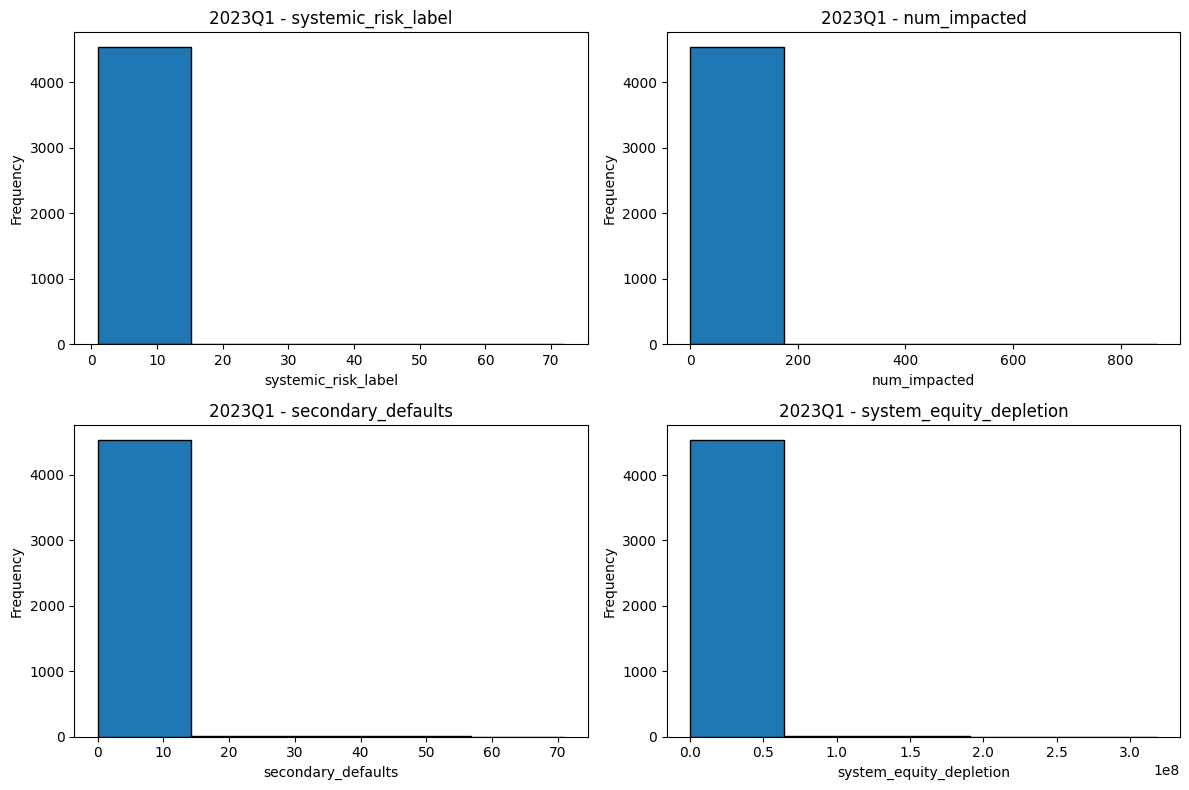

In [7]:
dist_cols = [
    'systemic_risk_label',
    'num_impacted',
    'secondary_defaults',
    'system_equity_depletion',
    'failed_equity_loss',
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, dist_cols):
    importance_df[col].plot(kind='hist', bins=5, ax=ax, edgecolor='black')
    ax.set_title(f'{YEAR}Q{QUARTER} - {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [8]:
quantiles = importance_df[
    ['systemic_risk_label', 'num_impacted', 'secondary_defaults', 'system_equity_depletion', 'failed_equity_loss']
].quantile([0.50, 0.75, 0.90, 0.95, 0.99])

display(quantiles)


,systemic_risk_label,num_impacted,secondary_defaults,system_equity_depletion,failed_equity_loss
0.50,1.0,1.00,0.0,3.219850e+04,2.957000e+04
0.75,1.0,2.00,0.0,9.100675e+04,8.507325e+04
0.90,1.0,3.00,0.0,4.392948e+05,4.171455e+05
0.95,1.0,4.00,0.0,1.765824e+06,1.672963e+06
0.99,4.0,46.06,3.0,1.787161e+07,1.696953e+07


## Table validation

In [9]:
runs_path = TABLE_DIRS['runs'] / f'sim_runs_{YEAR}Q{QUARTER}.parquet'
bank_state_path = TABLE_DIRS['bank_state'] / f'sim_bank_state_{YEAR}Q{QUARTER}.parquet'
round_summary_path = TABLE_DIRS['round_summary'] / f'sim_round_summary_{YEAR}Q{QUARTER}.parquet'
importance_path = TABLE_DIRS['importance'] / f'systemic_importance_{YEAR}Q{QUARTER}.parquet'

runs_check = pd.read_parquet(runs_path)
bank_state_check = pd.read_parquet(bank_state_path)
round_summary_check = pd.read_parquet(round_summary_path)
importance_check = pd.read_parquet(importance_path)

print(runs_check.shape)
print(bank_state_check.shape)
print(round_summary_check.shape)
print(importance_check.shape)


(4548, 27)
(17087, 14)
(4666, 7)
(4548, 26)


In [10]:
# Check 1: one run per initial bank
assert len(runs_check) == len(nodes), 'Expected one simulation run per bank.'

# Check 2: Table 1 num_failed must match the number of failed banks in Table 2
failed_counts = (
    bank_state_check[bank_state_check['failed']]
    .groupby('run_id')
    .size()
    .rename('failed_in_bank_state')
    .reset_index()
)

cross_check = runs_check[['run_id', 'num_failed']].merge(
    failed_counts,
    on='run_id',
    how='left',
)
cross_check['failed_in_bank_state'] = cross_check['failed_in_bank_state'].fillna(0).astype(int)

mismatches = cross_check[cross_check['num_failed'] != cross_check['failed_in_bank_state']]
print('Cross-table mismatches:', len(mismatches))
assert mismatches.empty, 'Tables are inconsistent.'

# Check 3: the ranking table must have one row per initial bank
assert len(importance_check) == len(nodes), 'Expected one ranking row per bank.'
assert importance_check['bank_id'].is_unique, 'Each bank should appear once in the ranking table.'

print('All validation checks passed.')


Cross-table mismatches: 0
All validation checks passed.


## Run all quarters

Generate outputs for the full 2016Q1–2023Q4 period.

In [11]:
all_quarter_summaries = []

for year in range(2016, 2024):
    for quarter in range(1, 5):
        outputs = run_default_contagion_analysis_for_quarter(
            year=year,
            quarter=quarter,
            data_path=DATA_PATH,
            output_dir=OUTPUT_ROOT,
            mechanism=MECHANISM,
            alpha=ALPHA,
            track_rounds=TRACK_ROUNDS,
        )

        importance = outputs['importance']
        all_quarter_summaries.append({
            'year': year,
            'quarter': quarter,
            'n_banks': len(importance),
            'max_systemic_risk_label': int(importance['systemic_risk_label'].max()),
            'max_cascade_size': int(importance['cascade_size'].max()),
            'max_secondary_defaults': int(importance['secondary_defaults'].max()),
            'max_system_equity_depletion': float(importance['system_equity_depletion'].max()),
        })

full_summary_df = pd.DataFrame(all_quarter_summaries)
display(full_summary_df)


Loaded 2016 Q1: 4548 banks, 11631 edges
Loaded 2016 Q2: 4548 banks, 11632 edges
Loaded 2016 Q3: 4548 banks, 11937 edges
Loaded 2016 Q4: 4548 banks, 11938 edges
Loaded 2017 Q1: 4548 banks, 11939 edges
Loaded 2017 Q2: 4548 banks, 11940 edges
Loaded 2017 Q3: 4548 banks, 11941 edges
Loaded 2017 Q4: 4548 banks, 11981 edges
Loaded 2018 Q1: 4548 banks, 12416 edges
Loaded 2018 Q2: 4548 banks, 12417 edges
Loaded 2018 Q3: 4548 banks, 12418 edges
Loaded 2018 Q4: 4548 banks, 12419 edges
Loaded 2019 Q1: 4548 banks, 12420 edges
Loaded 2019 Q2: 4548 banks, 12421 edges
Loaded 2019 Q3: 4548 banks, 12422 edges
Loaded 2019 Q4: 4548 banks, 12423 edges
Loaded 2020 Q1: 4548 banks, 12424 edges
Loaded 2020 Q2: 4548 banks, 12451 edges
Loaded 2020 Q3: 4548 banks, 12452 edges
Loaded 2020 Q4: 4548 banks, 12453 edges
Loaded 2021 Q1: 4548 banks, 12454 edges
Loaded 2021 Q2: 4548 banks, 12455 edges
Loaded 2021 Q3: 4548 banks, 12456 edges
Loaded 2021 Q4: 4548 banks, 12457 edges
Loaded 2022 Q1: 4548 banks, 12458 edges


,year,quarter,n_banks,max_systemic_risk_label,max_cascade_size,max_secondary_defaults,max_system_equity_depletion
0,2016,1,4548,215,215,214,5.185741e+08
1,2016,2,4548,112,112,111,3.762816e+08
2,2016,3,4548,65,65,64,3.232394e+08
3,2016,4,4548,28,28,27,2.785466e+08
4,2017,1,4548,33,33,32,2.435040e+08
5,2017,2,4548,41,41,40,2.156932e+08
6,2017,3,4548,34,34,33,2.176153e+08
7,2017,4,4548,31,31,30,2.165318e+08
8,2018,1,4548,40,40,39,2.199247e+08
9,2018,2,4548,37,37,36,2.209671e+08


## Log transformation of targets

`systemic_risk_label` is heavily right-skewed (75th pct = 1, max ≈ 215).  
`log1p` is monotonic — ordering is preserved, predictions can be inverted with `expm1`.  
Without it, the regressor is incentivised to predict ~1 for everyone and ignore the high-cascade banks.

In [12]:
import numpy as np
from pathlib import Path

TARGET_DIR = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_1' / 'targets'

frames = []
for csv_path in sorted(TARGET_DIR.glob('target_*.csv')):
    df = pd.read_csv(csv_path)
    df['log_systemic_risk_label'] = np.log1p(df['systemic_risk_label'])
    df.to_csv(csv_path, index=False)
    frames.append(df)

all_targets = pd.concat(frames, ignore_index=True)
print(f'Loaded and transformed {len(frames)} quarterly target files.')
print(f'Total rows: {len(all_targets):,}')
all_targets[['systemic_risk_label', 'log_systemic_risk_label']].describe()

Loaded and transformed 32 quarterly target files.
Total rows: 145,536


,systemic_risk_label,log_systemic_risk_label
count,145536.000000,145536.000000
mean,1.141346,0.715843
std,2.050631,0.187462
min,1.000000,0.693147
25%,1.000000,0.693147
50%,1.000000,0.693147
75%,1.000000,0.693147
max,215.000000,5.375278


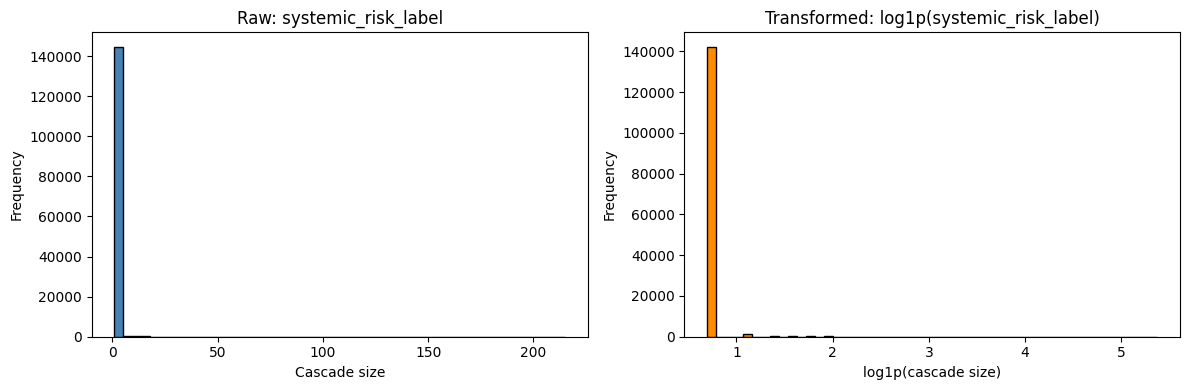

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

all_targets['systemic_risk_label'].plot(
    kind='hist', bins=50, ax=axes[0], edgecolor='black', color='steelblue'
)
axes[0].set_title('Raw: systemic_risk_label')
axes[0].set_xlabel('Cascade size')
axes[0].set_ylabel('Frequency')

all_targets['log_systemic_risk_label'].plot(
    kind='hist', bins=50, ax=axes[1], edgecolor='black', color='darkorange'
)
axes[1].set_title('Transformed: log1p(systemic_risk_label)')
axes[1].set_xlabel('log1p(cascade size)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Partial Loss Simulations (p = 10% – 40%)

In [ ]:
def run_contagion_for_p(edges, nodes, p, year, quarter):
    """
    Same as run_default_contagion_analysis but with a p% equity-loss
    default threshold: a bank defaults when it has lost >= (1-p)%
    of its equity, implemented by rescaling Equity = (1-p) * Equity.
    """
    nodes_p = nodes.copy()
    nodes_p['Equity'] = (1 - p) * nodes_p['Equity']
    return run_default_contagion_analysis(
        edges=edges,
        nodes=nodes_p,
        year=year,
        quarter=quarter,
        mechanism=MECHANISM,
        alpha=ALPHA,
        track_rounds=TRACK_ROUNDS,
        output_dir=None,
    )

In [ ]:
import numpy as np

P_THRESHOLDS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
TARGET_DIR = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_1' / 'targets'

for year in range(2016, 2024):
    for quarter in range(1, 5):
        edges, nodes = load_data(year, quarter, data_path=DATA_PATH)
        for p in P_THRESHOLDS:
            p_label = f'p{int(p * 100)}'
            tag = f'{year}Q{quarter}'

            # Subfolders per p threshold inside each table dir
            p_dirs = {key: path / p_label for key, path in TABLE_DIRS.items()}
            for d in p_dirs.values():
                d.mkdir(parents=True, exist_ok=True)
            target_p_dir = TARGET_DIR / p_label
            target_p_dir.mkdir(parents=True, exist_ok=True)

            out = run_contagion_for_p(edges, nodes, p, year, quarter)

            out['runs'].to_parquet(p_dirs['runs'] / f'sim_runs_{tag}.parquet', index=False)
            out['bank_state'].to_parquet(p_dirs['bank_state'] / f'sim_bank_state_{tag}.parquet', index=False)
            out['round_summary'].to_parquet(p_dirs['round_summary'] / f'sim_round_summary_{tag}.parquet', index=False)
            out['importance'].to_parquet(p_dirs['importance'] / f'systemic_importance_{tag}.parquet', index=False)

            target = out['target'].copy()
            target['log_systemic_risk_label'] = np.log1p(target['systemic_risk_label'])
            target.to_csv(target_p_dir / f'target_{tag}.csv', index=False)

        print(f'{year}Q{quarter} done')

print('All quarters done.')